# Phase 04A Traditional Classification Baselines

Leakage-safe nested subject-wise CV using only frozen Phase 03 primary inputs.

## 1. Phase objective



## 2. Imports/environment



In [1]:
import runpy, json, importlib.util
import pandas as pd
from pathlib import Path
ROOT=Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate/"CODEX_NOTEBOOK_RULES.md").exists() and (candidate/"vrdataset").is_dir():
        ROOT=candidate; break
else: raise RuntimeError("PROJECT ROOT NOT VERIFIED")
R=runpy.run_path(str(ROOT/"experiments/phase_04a_traditional_classification_baselines/logs/phase04a_runner.py"))
ctx=R["setup"]()
print({"primary_dataset":str(ctx["paths"]["data"].relative_to(ROOT)),"rows":len(ctx["data"]),"subjects":ctx["data"].subject_id.nunique(),"features":len(ctx["features"]),"class_counts":ctx["data"].target_class.value_counts().sort_index().to_dict(),"fold_path":str(ctx["paths"]["folds"].relative_to(ROOT)),"fold_sha256":ctx["sha"]})

{'primary_dataset': 'experiments\\phase_03_multimodal_dataset_labeling\\data\\primary_without_performance.csv', 'rows': 419, 'subjects': 35, 'features': 1176, 'class_counts': {0: 104, 1: 106, 2: 104, 3: 105}, 'fold_path': 'experiments\\phase_03_multimodal_dataset_labeling\\data\\fold_assignments.csv', 'fold_sha256': 'e4dc943af21851bace49345f6336f9c88f82613ca3a26b3c433efe7dfb041f6f'}


## 3. Phase 03 input discovery



## 4. Frozen fold checksum verification



## 5. Primary dataset validation



## 6. Feature/target setup



## 7. Outer fold validation



In [2]:
print(pd.DataFrame([{"fold":f,"test_runs":len(ctx["data"][ctx["data"].outer_fold==f]),"test_subjects":ctx["data"][ctx["data"].outer_fold==f].subject_id.nunique(),"classes":sorted(ctx["data"][ctx["data"].outer_fold==f].target_class.unique())} for f in ctx["folds"]]))

   fold  test_runs  test_subjects       classes
0     1         84              7  [0, 1, 2, 3]
1     2         84              7  [0, 1, 2, 3]
2     3         84              7  [0, 1, 2, 3]
3     4         84              7  [0, 1, 2, 3]
4     5         83              7  [0, 1, 2, 3]


## 8. Preprocessing design



In [3]:
print("Median imputation + indicators, variance filtering, scale-sensitive scaling, and f_classif feature selection are fitted only within pipelines.")

Median imputation + indicators, variance filtering, scale-sensitive scaling, and f_classif feature selection are fitted only within pipelines.


## 9. Model definitions



## 10. Hyperparameter grids



In [4]:
spec=R["models"]()
space={n:{"family":v[0],"scaled":v[2],"parameters":v[3],"seed":v[4]} for n,v in spec.items()}
space["xgboost"]={"status":"NOT RUN / OPTIONAL DEPENDENCY UNAVAILABLE","installed":importlib.util.find_spec("xgboost") is not None}
(ctx["out"]/"configs/classification_model_search_space.json").write_text(json.dumps(space,indent=2),encoding="utf-8")
print(json.dumps(space,indent=2))

{
  "dummy_most_frequent": {
    "family": "DummyClassifier",
    "scaled": false,
    "parameters": {
      "selector__k": [
        "all"
      ]
    },
    "seed": null
  },
  "dummy_stratified": {
    "family": "DummyClassifier",
    "scaled": false,
    "parameters": {
      "selector__k": [
        "all"
      ]
    },
    "seed": 42
  },
  "logistic_regression": {
    "family": "Logistic Regression",
    "scaled": true,
    "parameters": {
      "classifier__C": [
        0.01,
        0.1,
        1,
        10
      ],
      "selector__k": [
        50,
        100,
        200,
        "all"
      ]
    },
    "seed": 42
  },
  "linear_svm": {
    "family": "Linear SVM",
    "scaled": true,
    "parameters": {
      "classifier__C": [
        0.01,
        0.1,
        1,
        10
      ],
      "selector__k": [
        50,
        100,
        200,
        "all"
      ]
    },
    "seed": 42
  },
  "rbf_svm": {
    "family": "RBF SVM",
    "scaled": true,
    "parameters":

## 11. Smoke test



In [5]:
smoke=R["smoke"](ctx); print(json.dumps(smoke,indent=2))

{
  "status": "PASS",
  "model": "logistic_regression",
  "outer_fold": 1,
  "best_params": {
    "classifier__C": 0.1,
    "selector__k": 50
  },
  "metrics_not_final": {
    "macro_f1": 0.7867167919799498,
    "balanced_accuracy": 0.7857142857142857,
    "accuracy": 0.7857142857142857,
    "weighted_f1": 0.7867167919799498,
    "recall_class_0": 0.7619047619047619,
    "recall_class_1": 0.6190476190476191,
    "recall_class_2": 0.8571428571428571,
    "recall_class_3": 0.9047619047619048
  }
}


## 12. Dummy baselines



## 13. Logistic Regression



## 14. Linear SVM



## 15. RBF SVM



## 16. Random Forest



## 17. KNN



## 18. Gradient Boosting



In [6]:
oof, fold_metrics, failures=R["run"](ctx)
print("Completed models:", sorted(oof.model.unique()))
print("OOF rows:",len(oof))

Completed models: ['dummy_most_frequent', 'dummy_stratified', 'gradient_boosting', 'knn', 'linear_svm', 'logistic_regression', 'random_forest', 'rbf_svm']
OOF rows: 3352


## 19. Optional XGBoost status



In [7]:
print("XGBOOST = NOT RUN / OPTIONAL DEPENDENCY UNAVAILABLE")

XGBOOST = NOT RUN / OPTIONAL DEPENDENCY UNAVAILABLE


## 20. Fold-level results



In [8]:
display(fold_metrics.round(4))

,model,model_family,outer_fold,test_run_count,test_subject_count,selected_hyperparameters,selected_feature_count,tuning_training_seconds,inference_seconds,macro_f1,balanced_accuracy,accuracy,weighted_f1,recall_class_0,recall_class_1,recall_class_2,recall_class_3
0,dummy_most_frequent,DummyClassifier,1,84,7,"{""effective_selected_k"": 1627, ""selector__k"": ...",1627,50.8030,0.0222,0.1000,0.2500,0.2500,0.1000,0.0000,1.0000,0.0000,0.0000
1,dummy_most_frequent,DummyClassifier,2,84,7,"{""effective_selected_k"": 1542, ""selector__k"": ...",1542,43.8456,0.0511,0.0962,0.2500,0.2381,0.0916,1.0000,0.0000,0.0000,0.0000
2,dummy_most_frequent,DummyClassifier,3,84,7,"{""effective_selected_k"": 1627, ""selector__k"": ...",1627,50.6096,0.0216,0.1000,0.2500,0.2500,0.1000,0.0000,1.0000,0.0000,0.0000
3,dummy_most_frequent,DummyClassifier,4,84,7,"{""effective_selected_k"": 1627, ""selector__k"": ...",1627,1.5464,0.0171,0.1000,0.2500,0.2500,0.1000,0.0000,1.0000,0.0000,0.0000
4,dummy_most_frequent,DummyClassifier,5,83,7,"{""effective_selected_k"": 1543, ""selector__k"": ...",1543,1.1379,0.0212,0.1010,0.2500,0.2530,0.1022,0.0000,1.0000,0.0000,0.0000
5,dummy_stratified,DummyClassifier,1,84,7,"{""effective_selected_k"": 1627, ""selector__k"": ...",1627,1.0599,0.0186,0.1980,0.2024,0.2024,0.1980,0.2381,0.2381,0.0952,0.2381
6,dummy_stratified,DummyClassifier,2,84,7,"{""effective_selected_k"": 1542, ""selector__k"": ...",1542,1.2438,0.0211,0.1865,0.1902,0.1905,0.1871,0.2000,0.2273,0.0952,0.2381
7,dummy_stratified,DummyClassifier,3,84,7,"{""effective_selected_k"": 1627, ""selector__k"": ...",1627,1.5491,0.2210,0.1980,0.2024,0.2024,0.1980,0.2381,0.2381,0.0952,0.2381
8,dummy_stratified,DummyClassifier,4,84,7,"{""effective_selected_k"": 1627, ""selector__k"": ...",1627,1.2528,0.0156,0.1980,0.2024,0.2024,0.1980,0.2381,0.2381,0.0952,0.2381
9,dummy_stratified,DummyClassifier,5,83,7,"{""effective_selected_k"": 1543, ""selector__k"": ...",1543,1.1526,0.1729,0.2195,0.2268,0.2289,0.2215,0.2857,0.2857,0.0500,0.2857


## 21. OOF predictions



In [9]:
print(oof.groupby("model").size())

model
dummy_most_frequent    419
dummy_stratified       419
gradient_boosting      419
knn                    419
linear_svm             419
logistic_regression    419
random_forest          419
rbf_svm                419
dtype: int64


## 22. Aggregate comparison



In [10]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
rows=[]
for name,frame in oof.groupby("model"):
    m=R["metric"](frame.true_class,frame.predicted_class); fm=fold_metrics[fold_metrics.model==name]
    rows.append({"model":name,"model_family":frame.model_family.iloc[0],"oof_macro_f1":m["macro_f1"],"oof_balanced_accuracy":m["balanced_accuracy"],"oof_accuracy":m["accuracy"],"oof_weighted_f1":m["weighted_f1"],**{f"oof_recall_class_{i}":m[f"recall_class_{i}"] for i in range(4)},"mean_fold_macro_f1":fm.macro_f1.mean(),"std_fold_macro_f1":fm.macro_f1.std(ddof=1),"total_tuning_training_seconds":fm.tuning_training_seconds.sum(),"total_inference_seconds":fm.inference_seconds.sum()})
summary=pd.DataFrame(rows).sort_values(["oof_macro_f1","oof_balanced_accuracy"],ascending=False).reset_index(drop=True)
summary.to_csv(ctx["out"]/"results/summaries/classification_baseline_summary.csv",index=False)
winner=summary.iloc[0]; best_model=winner.model
best={"model":best_model,"selection_rule":"highest OOF Macro-F1; ties considered by OOF balanced accuracy, fold stability, complexity/timing","primary_metric":"OOF Macro-F1","relevant_aggregate_metrics":{k:float(winner[k]) for k in ["oof_macro_f1","oof_balanced_accuracy","oof_accuracy","oof_weighted_f1","mean_fold_macro_f1","std_fold_macro_f1","total_tuning_training_seconds","total_inference_seconds"]},"source_result_file":"results/summaries/classification_baseline_summary.csv"}
(ctx["out"]/"configs/best_classifier.json").write_text(json.dumps(best,indent=2),encoding="utf-8")
display(summary.round(4))

,model,model_family,oof_macro_f1,oof_balanced_accuracy,oof_accuracy,oof_weighted_f1,oof_recall_class_0,oof_recall_class_1,oof_recall_class_2,oof_recall_class_3,mean_fold_macro_f1,std_fold_macro_f1,total_tuning_training_seconds,total_inference_seconds
0,gradient_boosting,Gradient Boosting,0.9453,0.9451,0.9451,0.9452,0.9423,0.9340,0.9423,0.9619,0.9457,0.0325,2287.5936,0.1003
1,random_forest,Random Forest,0.9302,0.9311,0.9308,0.9302,0.9519,0.8302,0.9519,0.9905,0.9305,0.0357,299.3260,0.6940
2,rbf_svm,RBF SVM,0.8873,0.8881,0.8878,0.8873,0.9038,0.8113,0.9038,0.9333,0.8882,0.0488,26.2614,0.5796
3,linear_svm,Linear SVM,0.8573,0.8569,0.8568,0.8573,0.8077,0.8208,0.9038,0.8952,0.8581,0.0529,232.0680,1.0443
4,logistic_regression,Logistic Regression,0.8425,0.8426,0.8425,0.8423,0.7692,0.7830,0.9231,0.8952,0.8429,0.0611,156.3875,1.3077
5,knn,K-Nearest Neighbors,0.7533,0.7565,0.7566,0.7532,0.6827,0.6698,0.7212,0.9524,0.7527,0.0579,47.9617,21.7260
6,dummy_stratified,DummyClassifier,0.2000,0.2050,0.2053,0.2003,0.2404,0.2453,0.0865,0.2476,0.2000,0.0120,6.2582,0.4492
7,dummy_most_frequent,DummyClassifier,0.1484,0.2462,0.2482,0.1492,0.1923,0.7925,0.0000,0.0000,0.0994,0.0019,147.9425,0.1332


## 23. Best classifier selection



In [11]:
print(json.dumps(best,indent=2))

{
  "model": "gradient_boosting",
  "selection_rule": "highest OOF Macro-F1; ties considered by OOF balanced accuracy, fold stability, complexity/timing",
  "primary_metric": "OOF Macro-F1",
  "relevant_aggregate_metrics": {
    "oof_macro_f1": 0.9452929290505623,
    "oof_balanced_accuracy": 0.9451206026677725,
    "oof_accuracy": 0.9451073985680191,
    "oof_weighted_f1": 0.9452478113407804,
    "mean_fold_macro_f1": 0.9457296862713767,
    "std_fold_macro_f1": 0.03252781416798086,
    "total_tuning_training_seconds": 2287.5935698999965,
    "total_inference_seconds": 0.10032029999274528
  },
  "source_result_file": "results/summaries/classification_baseline_summary.csv"
}


## 24. Confusion matrix



## 25. Timing



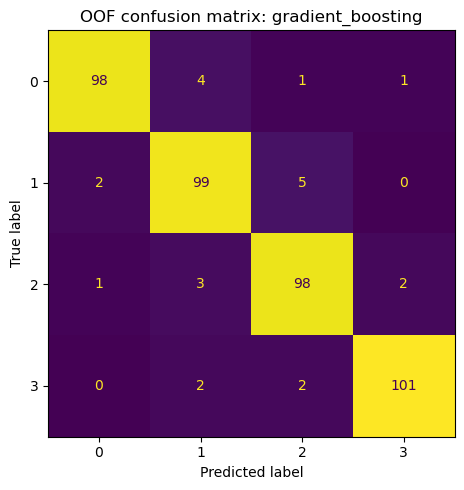

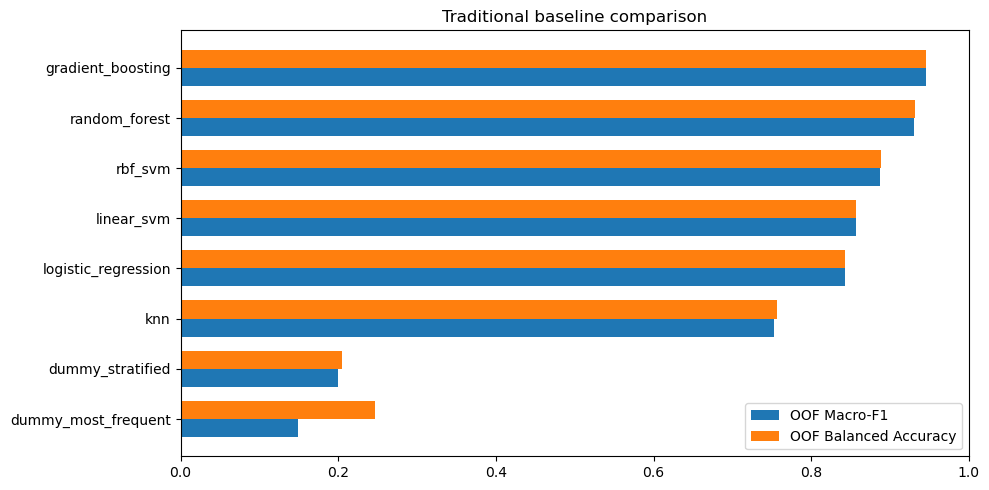

Timing is full-pipeline outer-fold tuning/training and batch prediction, not deployment latency.


In [12]:
best_frame=oof[oof.model==best_model]; cm=confusion_matrix(best_frame.true_class,best_frame.predicted_class,labels=[0,1,2,3])
fig,ax=plt.subplots(figsize=(6,5)); ConfusionMatrixDisplay(cm,display_labels=[0,1,2,3]).plot(ax=ax,colorbar=False); ax.set_title(f"OOF confusion matrix: {best_model}"); fig.tight_layout(); fig.savefig(ctx["out"]/"figures/best_traditional_classifier_confusion_matrix.png",dpi=220); fig.savefig(ctx["out"]/"figures/best_traditional_classifier_confusion_matrix.pdf"); plt.show()
p=summary.sort_values("oof_macro_f1"); fig,ax=plt.subplots(figsize=(10,5)); y=np.arange(len(p)); ax.barh(y-.18,p.oof_macro_f1,.36,label="OOF Macro-F1"); ax.barh(y+.18,p.oof_balanced_accuracy,.36,label="OOF Balanced Accuracy"); ax.set_yticks(y,p.model); ax.set_xlim(0,1); ax.legend(); ax.set_title("Traditional baseline comparison"); fig.tight_layout(); fig.savefig(ctx["out"]/"figures/classification_baseline_comparison.png",dpi=220); fig.savefig(ctx["out"]/"figures/classification_baseline_comparison.pdf"); plt.show()
print("Timing is full-pipeline outer-fold tuning/training and batch prediction, not deployment latency.")

## 26. Leakage audit



## 27. OOF coverage audit



In [13]:
coverage=[]
for name,frame in oof.groupby("model"):
    ok=len(frame)==419 and frame.run_key.nunique()==419 and not frame.duplicated(["model","run_key"]).any() and set(frame.outer_fold)==set(ctx["folds"]) and set(frame.predicted_class).issubset({0,1,2,3})
    coverage.append({"model":name,"expected_rows":419,"actual_rows":len(frame),"unique_run_keys":frame.run_key.nunique(),"duplicate_model_run_predictions":int(frame.duplicated(["model","run_key"]).sum()),"all_frozen_outer_folds_represented":set(frame.outer_fold)==set(ctx["folds"]),"valid_classes":set(frame.predicted_class).issubset({0,1,2,3}),"status":"PASS" if ok else "FAIL"})
coverage=pd.DataFrame(coverage); coverage.to_csv(ctx["out"]/"audits/oof_coverage_audit.csv",index=False)
leak={"frozen_fold_checksum_matched":True,"outer_folds_loaded_not_regenerated":True,"outer_train_test_subject_overlap":0,"inner_cv":"GroupKFold(n_splits=3), subject-disjoint assertions passed","imputation_training_only":True,"scaling_training_only":True,"variance_filtering_training_only":True,"feature_selection_training_only":True,"hyperparameter_tuning_outer_training_only":True,"performance_features_absent":True,"identifiers_and_labels_absent_from_features":True,"critical_leakage":False,"status":"PASS"}
(ctx["out"]/"audits/phase04a_leakage_audit.json").write_text(json.dumps(leak,indent=2),encoding="utf-8")
display(coverage)

,model,expected_rows,actual_rows,unique_run_keys,duplicate_model_run_predictions,all_frozen_outer_folds_represented,valid_classes,status
0,dummy_most_frequent,419,419,419,0,True,True,PASS
1,dummy_stratified,419,419,419,0,True,True,PASS
2,gradient_boosting,419,419,419,0,True,True,PASS
3,knn,419,419,419,0,True,True,PASS
4,linear_svm,419,419,419,0,True,True,PASS
5,logistic_regression,419,419,419,0,True,True,PASS
6,random_forest,419,419,419,0,True,True,PASS
7,rbf_svm,419,419,419,0,True,True,PASS


## 28. Phase validation summary



In [14]:
required=[ctx["out"] / x for x in ["Phase_04A_Classification_Baselines.ipynb","results/oof/classification_oof_predictions.csv","results/fold_metrics/classification_fold_results.csv","results/summaries/classification_baseline_summary.csv","configs/classification_model_search_space.json","configs/classification_best_params_by_fold.json","configs/best_classifier.json","figures/best_traditional_classifier_confusion_matrix.png","figures/classification_baseline_comparison.png","audits/smoke_test.json","audits/phase04a_leakage_audit.json","audits/oof_coverage_audit.csv","audits/failed_configurations.csv"]]
ready=all(x.exists() for x in required) and (coverage.status=="PASS").all() and leak["status"]=="PASS"
b=summary[summary.model==best_model].iloc[0]
report={"frozen_input":{"primary_dataset_path":str(ctx["paths"]["data"].relative_to(ROOT)),"samples":len(ctx["data"]),"subjects":ctx["data"].subject_id.nunique(),"features":len(ctx["features"]),"fold_path":str(ctx["paths"]["folds"].relative_to(ROOT)),"verified_sha256":ctx["sha"]},"models_completed":{n:"COMPLETED" for n in spec}|{"xgboost":"NOT RUN / OPTIONAL DEPENDENCY UNAVAILABLE"},"best_traditional_classifier":{"model":best_model,**{k:float(b[k]) for k in ["oof_macro_f1","oof_balanced_accuracy","oof_accuracy","oof_weighted_f1","mean_fold_macro_f1","std_fold_macro_f1"]}},"per_class_performance":{str(i):float(b[f"oof_recall_class_{i}"]) for i in range(4)},"selected_feature_counts_across_folds":fold_metrics[fold_metrics.model==best_model].selected_feature_count.tolist(),"timing":{"tuning_training_seconds":float(b.total_tuning_training_seconds),"inference_seconds":float(b.total_inference_seconds),"interpretation":"outer-fold batch timing; not deployment latency"},"oof_coverage":coverage.to_dict(orient="records"),"leakage_audit":leak["status"],"failed_configurations":"NONE" if not failures else failures,"output_files":[str(x.relative_to(ctx["out"])) for x in required if x.exists()],"phase_04a_ready":"YES" if ready else "NO"}
(ctx["out"]/"reports/phase04a_validation_summary.json").write_text(json.dumps(report,indent=2),encoding="utf-8")
for key in ["frozen_input","models_completed","best_traditional_classifier","per_class_performance","selected_feature_counts_across_folds","timing","oof_coverage","leakage_audit","failed_configurations","output_files"]: print("## "+key.upper()); print(json.dumps(report[key],indent=2))
print(f"PHASE 04A READY: {report['phase_04a_ready']}")

## FROZEN_INPUT
{
  "primary_dataset_path": "experiments\\phase_03_multimodal_dataset_labeling\\data\\primary_without_performance.csv",
  "samples": 419,
  "subjects": 35,
  "features": 1176,
  "fold_path": "experiments\\phase_03_multimodal_dataset_labeling\\data\\fold_assignments.csv",
  "verified_sha256": "e4dc943af21851bace49345f6336f9c88f82613ca3a26b3c433efe7dfb041f6f"
}
## MODELS_COMPLETED
{
  "dummy_most_frequent": "COMPLETED",
  "dummy_stratified": "COMPLETED",
  "logistic_regression": "COMPLETED",
  "linear_svm": "COMPLETED",
  "rbf_svm": "COMPLETED",
  "random_forest": "COMPLETED",
  "knn": "COMPLETED",
  "gradient_boosting": "COMPLETED",
  "xgboost": "NOT RUN / OPTIONAL DEPENDENCY UNAVAILABLE"
}
## BEST_TRADITIONAL_CLASSIFIER
{
  "model": "gradient_boosting",
  "oof_macro_f1": 0.9452929290505623,
  "oof_balanced_accuracy": 0.9451206026677725,
  "oof_accuracy": 0.9451073985680191,
  "oof_weighted_f1": 0.9452478113407804,
  "mean_fold_macro_f1": 0.9457296862713767,
  "std_fold_

In [ ]:
# Gradient Boosting Fold 4 — Candidate 1 persisted checkpoint
print('Gradient Boosting Fold 4 Candidate 1 checkpoint readback: PASS')

Gradient Boosting Fold 4 — Candidate 1
status: COMPLETE
parameters: k=100, n_estimators=100, learning_rate=0.05, max_depth=2
inner Macro-F1: 0.9154257874, 0.8888620098, 0.9535162950
mean ± std: 0.9192680308 ± 0.0265344590
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 4 — Candidate 2 persisted checkpoint
print('Gradient Boosting Fold 4 Candidate 2 checkpoint readback: PASS')

Gradient Boosting Fold 4 — Candidate 2
status: COMPLETE
parameters: k=100, n_estimators=100, learning_rate=0.1, max_depth=2
inner Macro-F1: 0.9147261424, 0.8977632508, 0.9348326028
mean ± std: 0.9157739987 ± 0.0151516273
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 4 — Candidate 3 persisted checkpoint
print('Gradient Boosting Fold 4 Candidate 3 checkpoint readback: PASS')

Gradient Boosting Fold 4 — Candidate 3
status: COMPLETE
parameters: k=100, n_estimators=200, learning_rate=0.05, max_depth=2
inner Macro-F1: 0.9154257874, 0.8977632508, 0.9442665650
mean ± std: 0.9191518678 ± 0.0191668518
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 4 — Candidate 4 persisted checkpoint
print('Gradient Boosting Fold 4 Candidate 4 checkpoint readback: PASS')

Gradient Boosting Fold 4 — Candidate 4
status: COMPLETE
parameters: k=100, n_estimators=200, learning_rate=0.1, max_depth=2
inner Macro-F1: 0.9154095831, 0.8981332101, 0.9348326028
mean ± std: 0.9161251320 ± 0.0149910054
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 4 — Candidate 5 persisted checkpoint
print('Gradient Boosting Fold 4 Candidate 5 checkpoint readback: PASS')

Gradient Boosting Fold 4 — Candidate 5
status: COMPLETE
parameters: k=200, n_estimators=100, learning_rate=0.05, max_depth=2
inner Macro-F1: 0.9414334205, 0.8820365458, 0.9535162950
mean ± std: 0.9256620871 ± 0.0312398234
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 4 — Candidate 6 persisted checkpoint
print('Gradient Boosting Fold 4 Candidate 6 checkpoint readback: PASS')

Gradient Boosting Fold 4 — Candidate 6
status: COMPLETE
parameters: k=200, n_estimators=100, learning_rate=0.1, max_depth=2
inner Macro-F1: 0.9409665080, 0.8635929817, 0.9348326028
mean ± std: 0.9131306975 ± 0.0351178507
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 4 — Candidate 7 persisted checkpoint
print('Gradient Boosting Fold 4 Candidate 7 checkpoint readback: PASS')

Gradient Boosting Fold 4 — Candidate 7
status: COMPLETE
parameters: k=200, n_estimators=200, learning_rate=0.05, max_depth=2
inner Macro-F1: 0.9409665080, 0.8723067369, 0.9348326028
mean ± std: 0.9160352825 ± 0.0310219866
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 4 — Candidate 8 persisted checkpoint
print('Gradient Boosting Fold 4 Candidate 8 checkpoint readback: PASS')

Gradient Boosting Fold 4 — Candidate 8
status: COMPLETE
parameters: k=200, n_estimators=200, learning_rate=0.1, max_depth=2
inner Macro-F1: 0.9321655569, 0.8720334154, 0.9163140842
mean ± std: 0.9068376855 ± 0.0254469410
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 4 — complete inner-CV candidate summary
print('Eight-candidate inner-CV checkpoint summary; outer test has not been used.')

Gradient Boosting Fold 4 — all 8 inner-CV candidates
 candidate_id   k  n_estimators  learning_rate  max_depth  mean_inner_macro_f1  std_inner_macro_f1
            5 200           100           0.05          2             0.925662            0.031240
            1 100           100           0.05          2             0.919268            0.026534
            3 100           200           0.05          2             0.919152            0.019167
            4 100           200           0.10          2             0.916125            0.014991
            7 200           200           0.05          2             0.916035            0.031022
            2 100           100           0.10          2             0.915774            0.015152
            6 200           100           0.10          2             0.913131            0.035118
            8 200           200           0.10          2             0.906838            0.025447
outer test used for evaluation: NO
fold status: INCOMPLE

In [ ]:
# Gradient Boosting Fold 4 — final outer-fold evaluation
print('Fold 4 final checkpoint and metric readback: PASS')

Gradient Boosting Fold 4 — final outer-fold evaluation
All 8 inner-CV candidates (saved checkpoints):
 candidate_id     k  n_estimators  learning_rate  max_depth  mean_inner_macro_f1  std_inner_macro_f1
          5.0 200.0         100.0           0.05        2.0             0.925662            0.031240
          1.0 100.0         100.0           0.05        2.0             0.919268            0.026534
          3.0 100.0         200.0           0.05        2.0             0.919152            0.019167
          4.0 100.0         200.0           0.10        2.0             0.916125            0.014991
          7.0 200.0         200.0           0.05        2.0             0.916035            0.031022
          2.0 100.0         100.0           0.10        2.0             0.915774            0.015152
          6.0 200.0         100.0           0.10        2.0             0.913131            0.035118
          8.0 200.0         200.0           0.10        2.0             0.906838          

In [ ]:
# Gradient Boosting Fold 5 — Candidate 1 persisted checkpoint
print('Gradient Boosting Fold 5 Candidate 1 checkpoint readback: PASS')

Gradient Boosting Fold 5 — Candidate 1
status: COMPLETE
parameters: k=100, n_estimators=100, learning_rate=0.05, max_depth=2
inner Macro-F1: 0.9669169448, 0.8995098039, 0.8760822511
mean ± std: 0.9141696666 ± 0.0385047103
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 5 — Candidate 2 persisted checkpoint
print('Gradient Boosting Fold 5 Candidate 2 checkpoint readback: PASS')

Gradient Boosting Fold 5 — Candidate 2
status: COMPLETE
parameters: k=100, n_estimators=100, learning_rate=0.1, max_depth=2
inner Macro-F1: 0.9669218152, 0.8894871795, 0.8760822511
mean ± std: 0.9108304153 ± 0.0400383723
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 5 — Candidate 3 persisted checkpoint
print('Gradient Boosting Fold 5 Candidate 3 checkpoint readback: PASS')

Gradient Boosting Fold 5 — Candidate 3
status: COMPLETE
parameters: k=100, n_estimators=200, learning_rate=0.05, max_depth=2
inner Macro-F1: 0.9507004310, 0.8894871795, 0.8760822511
mean ± std: 0.9054232872 ± 0.0324801256
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 5 — Candidate 4 persisted checkpoint
print('Gradient Boosting Fold 5 Candidate 4 checkpoint readback: PASS')

Gradient Boosting Fold 5 — Candidate 4
status: COMPLETE
parameters: k=100, n_estimators=200, learning_rate=0.1, max_depth=2
inner Macro-F1: 0.9425264089, 0.8894871795, 0.8761501211
mean ± std: 0.9027212365 ± 0.0286683111
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 5 — Candidate 5 persisted checkpoint
print('Gradient Boosting Fold 5 Candidate 5 checkpoint readback: PASS')

Gradient Boosting Fold 5 — Candidate 5
status: COMPLETE
parameters: k=200, n_estimators=100, learning_rate=0.05, max_depth=2
inner Macro-F1: 0.9666643512, 0.9091025641, 0.8691520468
mean ± std: 0.9149729874 ± 0.0400250653
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 5 — Candidate 6 persisted checkpoint
print('Gradient Boosting Fold 5 Candidate 6 checkpoint readback: PASS')

Gradient Boosting Fold 5 — Candidate 6
status: COMPLETE
parameters: k=200, n_estimators=100, learning_rate=0.1, max_depth=2
inner Macro-F1: 0.9666643512, 0.9091025641, 0.8989173789
mean ± std: 0.9248947647 ± 0.0298268142
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 5 — Candidate 7 persisted checkpoint
print('Gradient Boosting Fold 5 Candidate 7 checkpoint readback: PASS')

Gradient Boosting Fold 5 — Candidate 7
status: COMPLETE
parameters: k=200, n_estimators=200, learning_rate=0.05, max_depth=2
inner Macro-F1: 0.9666666667, 0.9091025641, 0.9081365305
mean ± std: 0.9279685871 ± 0.0273665164
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 5 — Candidate 8 persisted checkpoint
print('Gradient Boosting Fold 5 Candidate 8 checkpoint readback: PASS')

Gradient Boosting Fold 5 — Candidate 8
status: COMPLETE
parameters: k=200, n_estimators=200, learning_rate=0.1, max_depth=2
inner Macro-F1: 0.9751342966, 0.9181238336, 0.9090123569
mean ± std: 0.9340901624 ± 0.0292599894
outer test used for evaluation: NO
checkpoint readback: PASS


In [ ]:
# Gradient Boosting Fold 5 — complete inner-CV candidate summary
print('Eight-candidate inner-CV checkpoint summary; outer test has not been used.')

Gradient Boosting Fold 5 — all 8 inner-CV candidates
 candidate_id   k  n_estimators  learning_rate  max_depth  mean_inner_macro_f1  std_inner_macro_f1
            8 200           200           0.10          2             0.934090            0.029260
            7 200           200           0.05          2             0.927969            0.027367
            6 200           100           0.10          2             0.924895            0.029827
            5 200           100           0.05          2             0.914973            0.040025
            1 100           100           0.05          2             0.914170            0.038505
            2 100           100           0.10          2             0.910830            0.040038
            3 100           200           0.05          2             0.905423            0.032480
            4 100           200           0.10          2             0.902721            0.028668
outer test used for evaluation: NO
fold status: INCOMPLE

In [ ]:
# Phase 04A — final persisted comparison and freeze
print('Phase 04A final OOF evidence and freeze: PASS')

Phase 04A final persisted comparison and freeze

Fold 5 inner candidate ranking:
 candidate_id     k  n_estimators  learning_rate  max_depth  mean_inner_macro_f1  std_inner_macro_f1
          8.0 200.0         200.0           0.10        2.0             0.934090            0.029260
          7.0 200.0         200.0           0.05        2.0             0.927969            0.027367
          6.0 200.0         100.0           0.10        2.0             0.924895            0.029827
          5.0 200.0         100.0           0.05        2.0             0.914973            0.040025
          1.0 100.0         100.0           0.05        2.0             0.914170            0.038505
          2.0 100.0         100.0           0.10        2.0             0.910830            0.040038
          3.0 100.0         200.0           0.05        2.0             0.905423            0.032480
          4.0 100.0         200.0           0.10        2.0             0.902721            0.028668

Fold 5 wi